# 24 · GSE135779 · scRNA_seq · WGCNA soft threshold

Reads `expression.rds`. Writes `data/run_artifacts/GSE135779/wgcna_input.rds`.

**Samples:** the 33 children with SLE, one sample each, as for GSE65391 (modules from SLE patients
only). **Genes:** all genes kept in notebook 23. **Network:** signed.
**Rule for β:** the lowest power with scale-free R² ≥ 0.80; if none, the FAQ fallback for a signed
network with 30–40 samples is 14.

In [1]:
if (!requireNamespace("WGCNA", quietly = TRUE)) install.packages("WGCNA", repos = "https://cloud.r-project.org")
suppressMessages(library(WGCNA))
source("../src/paths.R")
x <- readRDS(art("GSE135779", "expression.rds"))
datExpr <- t(x$E[, x$meta$sle == 1])
gsg <- goodSamplesGenes(datExpr, verbose = 0)
c(genes_flagged = sum(!gsg$goodGenes), samples_flagged = sum(!gsg$goodSamples))
datExpr <- datExpr[gsg$goodSamples, gsg$goodGenes]
dim(datExpr)

genes_flagged samples_flagged 
              0               0

[1]    33 15353

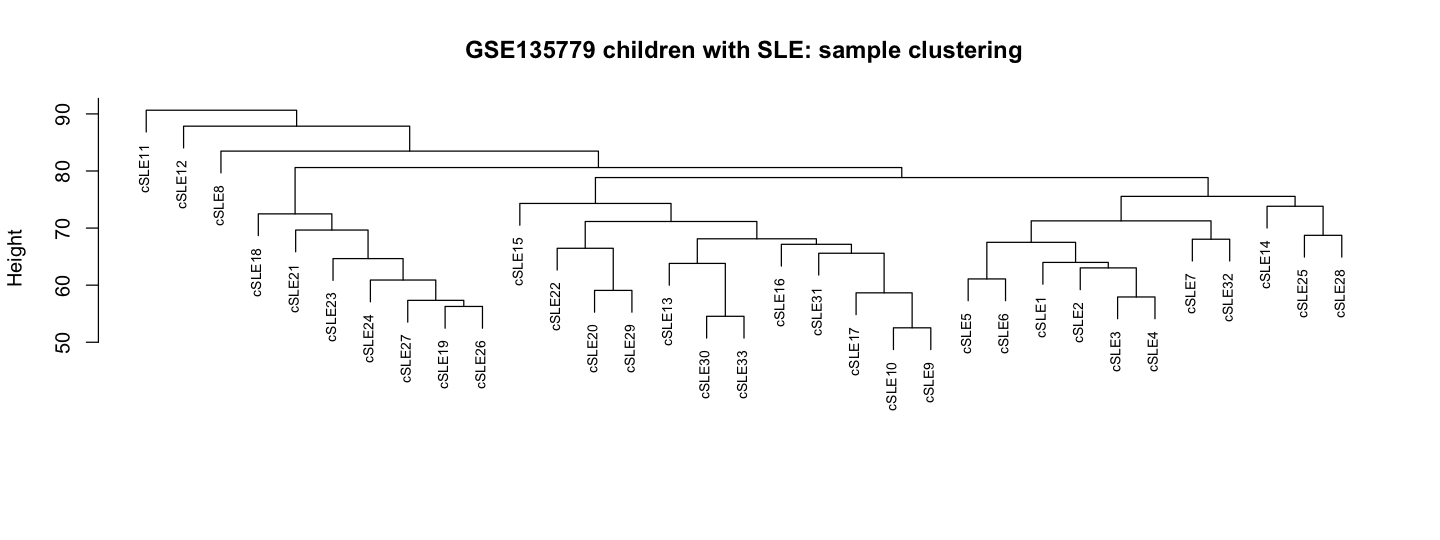

In [2]:
options(repr.plot.width = 12, repr.plot.height = 4.5)
plot(hclust(dist(datExpr), method = "average"), labels = x$meta[rownames(datExpr), "donor"], main = "GSE135779 children with SLE: sample clustering", xlab = "", sub = "", cex = 0.7)

In [3]:
powers <- c(1:10, seq(12, 30, 2))
invisible(capture.output(sft <- pickSoftThreshold(datExpr, powerVector = powers, networkType = "signed", verbose = 0)))
fit <- data.frame(power = sft$fitIndices$Power,
                  scale_free_R2 = round(-sign(sft$fitIndices$slope) * sft$fitIndices$SFT.R.sq, 3),
                  mean_connectivity = round(sft$fitIndices$mean.k., 1))
fit
reached <- fit$power[fit$scale_free_R2 >= 0.80]
POWER <- if (length(reached)) min(reached) else 14
c(power = POWER, rule = if (length(reached)) "lowest power with R2 >= 0.80" else "FAQ fallback, signed, 30-40 samples")
saveRDS(list(datExpr = datExpr, power = POWER, fit = fit), art("GSE135779", "wgcna_input.rds"))

Warning message:
“executing %dopar% sequentially: no parallel backend registered”


power,scale_free_R2,mean_connectivity
<dbl>,<dbl>,<dbl>
1,-0.172,7731.2
2,0.025,4204.8
3,0.219,2436.3
4,0.441,1488.5
5,0.572,951.4
6,0.643,632.1
7,0.704,434.3
8,0.756,307.3
9,0.795,223.0


power                           rule 
                          "10" "lowest power with R2 >= 0.80"

**Result.** 33 children × 15,353 genes, nothing flagged. β = 10, the lowest power with R² ≥ 0.80 (R² = 0.824).